# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [1]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [2]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [3]:
import urllib.request
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    urllib.request.urlretrieve(dataset_url, zip_path) #Change to urllib since MacOS doesn't have wget
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 4. Load the Data


In [4]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # 1. Load X_train from train/X_train.txt
    # 2. Load y_train from train/y_train.txt
    # 3. Load X_test from test/X_test.txt
    # 4. Load y_test from test/y_test.txt
    # 5. Convert the labels to zero-based class indices by subtracting 1

    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"))
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt")).astype(int) - 1

    X_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt"))
    y_test = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt")).astype(int) - 1

    return X_train, y_train, X_test, y_test
    raise NotImplementedError("Complete the data-loading function.")

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# define num_features and num_classes
num_features = X_train.shape[1]
num_classes = len(np.unique(y_train))


## 5. Quick Inspection


In [5]:
# Create a small summary table showing the class index, class name, and number of training samples.

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Number of input features:", num_features)
print("Number of classes:", num_classes)
label_counts = pd.Series(y_train).value_counts().sort_index()
summary_df = pd.DataFrame({
    "Class Index": range(num_classes),
    "Class Name": class_names,
    "Training Samples": label_counts.values
})
summary_df

X_train shape: (7352, 561)
X_test shape : (2947, 561)
Number of input features: 561
Number of classes: 6


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [6]:
def build_baseline_model(input_dim, num_classes) -> tf.keras.Model:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(256, activation="relu", name="Dense1")(inputs)
    x = layers.Dense(128, activation="relu", name="Dense2")(x)
    x = layers.Dense(64, activation="relu", name="Dense3")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="classifier")(x)
    return keras.Model(inputs,outputs, name="baseline_model")

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"],
)
baseline_model.summary()

Model: "baseline_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 561)]             0         
                                                                 
 Dense1 (Dense)              (None, 256)               143872    
                                                                 
 Dense2 (Dense)              (None, 128)               32896     
                                                                 
 Dense3 (Dense)              (None, 64)                8256      
                                                                 
 classifier (Dense)          (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [7]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

history_baseline = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    verbose=1,
    callbacks=callbacks,
)


Epoch 1/40
92/92 [==============================] - 0s 2ms/step - loss: 0.4880 - accuracy: 0.8073 - val_loss: 0.2027 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 1ms/step - loss: 0.1655 - accuracy: 0.9361 - val_loss: 0.1358 - val_accuracy: 0.9368
Epoch 3/40
92/92 [==============================] - 0s 1ms/step - loss: 0.1252 - accuracy: 0.9505 - val_loss: 0.1966 - val_accuracy: 0.9273
Epoch 4/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0981 - accuracy: 0.9595 - val_loss: 0.1258 - val_accuracy: 0.9443
Epoch 5/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0756 - accuracy: 0.9719 - val_loss: 0.1641 - val_accuracy: 0.9266
Epoch 6/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0692 - accuracy: 0.9755 - val_loss: 0.2387 - val_accuracy: 0.9252
Epoch 7/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0602 - accuracy: 0.9767 - val_loss: 0.1413 - val_accuracy: 0.9429
Epoch 8/40
92/92 [==

### Training Curves


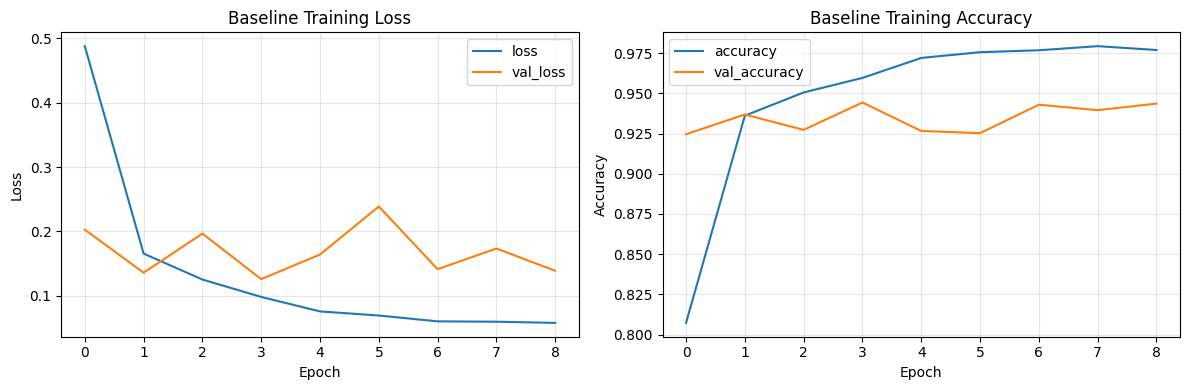

In [8]:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

history_df = pd.DataFrame(history_baseline.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

history_df[["loss", "val_loss"]].plot(ax=axes[0], title="Baseline Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

history_df[["accuracy", "val_accuracy"]].plot(ax=axes[1], title="Baseline Training Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Evaluate the Baseline Keras Model


93/93 [==============================] - 0s 642us/step
Accuracy 0.9290804207668816
Classification Report
                    precision    recall  f1-score   support

           WALKING       0.90      0.98      0.94       496
  WALKING_UPSTAIRS       0.95      0.88      0.92       471
WALKING_DOWNSTAIRS       0.94      0.92      0.93       420
           SITTING       0.93      0.87      0.90       491
          STANDING       0.86      0.94      0.90       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.93      2947
         macro avg       0.93      0.93      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



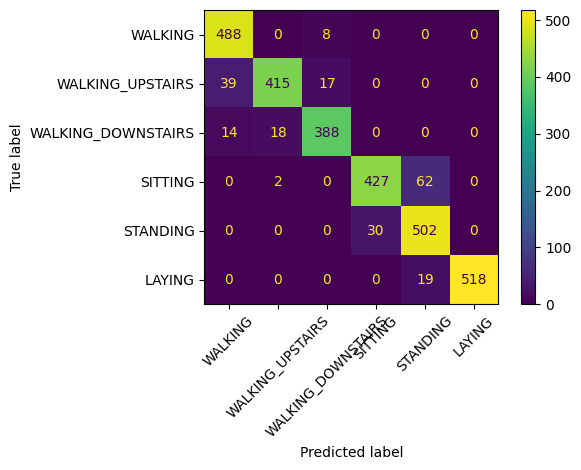

In [9]:
# 1. Obtain predicted probabilities on X_test
# 2. Convert them to class predictions using argmax
# 3. Compute test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

X_test_probabilities = baseline_model.predict(X_test)
X_test_predictions = np.argmax(X_test_probabilities, axis=1)
accuracy = accuracy_score(y_test, X_test_predictions)
print("Accuracy",accuracy)
print("Classification Report")
print(classification_report(y_test, X_test_predictions, target_names=class_names))

cm = confusion_matrix(y_test, X_test_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=45)
plt.tight_layout()
plt.show()

## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [10]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item should be in the form: [sample]

    for sample in X_train[:300]:
        yield [sample[np.newaxis, ...].astype(np.float32)]

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)
        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        if input_details["dtype"]==np.int8:
            if input_scale == 0:
                raise ValueError("INT8 model has invalid input quantization scale 0.")
            x = np.round(x/input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"]==np.uint8:
            if input_scale == 0:
                raise ValueError("UINT8 model has invalid input quantization scale 0.")
            x = np.round(x/input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # If the output is quantized, dequantize it back to float32.
        if output_details["dtype"] in (np.int8, np.uint8) and output_scale != 0:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # return the converted FP32 TensorFlow Lite model
    
    return converter.convert()

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # Apply default optimization and return the converted model.
    
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model
    
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()
    

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # Apply default optimization
    # Attach representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    # Set inference_input_type and inference_output_type to tf.int8
    # Return the converted model
    
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()


## 9. Post-Training Quantization (PTQ)


In [11]:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.
OUTPUT_DIR = Path("quantization_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
tflite_fp32 = convert_to_tflite_fp32(baseline_model)
tflite_dynamic = convert_to_tflite_dynamic_range(baseline_model)
tflite_float16 = convert_to_tflite_float16(baseline_model)
tflite_int8 = convert_to_tflite_int8(baseline_model)

size_fp32 = save_binary_model(tflite_fp32, OUTPUT_DIR/"fp32.tflite")
size_dynamic = save_binary_model(tflite_dynamic, OUTPUT_DIR/"dynamic.tflite")
size_float16 = save_binary_model(tflite_float16, OUTPUT_DIR/"float16.tflite")
size_int8 = save_binary_model(tflite_int8, OUTPUT_DIR/"int8.tflite")

accuracy_fp32, fp32_pred = evaluate_tflite_model(tflite_fp32, X_test, y_test)
accuracy_dynamic, dynamic_pred = evaluate_tflite_model(tflite_dynamic, X_test, y_test)
accuracy_float16, float16_pred = evaluate_tflite_model(tflite_float16, X_test, y_test)
accuracy_int8, int8_pred = evaluate_tflite_model(tflite_int8, X_test, y_test)

INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpwdujvyn9/assets


INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpwdujvyn9/assets
2026-04-18 02:23:25.723181: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-18 02:23:25.723191: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-18 02:23:25.723351: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpwdujvyn9
2026-04-18 02:23:25.723795: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-18 02:23:25.723799: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpwdujvyn9
2026-04-18 02:23:25.724601: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-04-18 02:23:25.725007: I tensorflow/cc/saved_model/load

INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmp5u1znt7b/assets


INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmp5u1znt7b/assets
2026-04-18 02:23:25.988816: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-18 02:23:25.988825: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-18 02:23:25.988920: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmp5u1znt7b
2026-04-18 02:23:25.989351: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-18 02:23:25.989354: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmp5u1znt7b
2026-04-18 02:23:25.990486: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-18 02:23:26.010853: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpzivtvbew/assets


INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpzivtvbew/assets
2026-04-18 02:23:26.343293: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-18 02:23:26.343304: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-18 02:23:26.343396: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpzivtvbew
2026-04-18 02:23:26.343815: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-18 02:23:26.343818: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpzivtvbew
2026-04-18 02:23:26.344975: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-18 02:23:26.365401: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpifrl3awb/assets


INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpifrl3awb/assets
/Users/nick/College Schoolwork Local/SP26/EE446/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-18 02:23:26.608539: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-18 02:23:26.608551: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-18 02:23:26.608646: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpifrl3awb
2026-04-18 02:23:26.609058: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-18 02:23:26.609062: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/fol

## 10. PTQ Comparison: Accuracy and Model Size


In [12]:
# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)
df_data = {
    "Model Family": ["baseline DNN"] * 4,
    "Format": ["FP32", "dynamic", "float16", "int8"],
    "Test Accuracy": [accuracy_fp32, accuracy_dynamic, accuracy_float16, accuracy_int8],
    "Model Size (KB)": [size_fp32, size_dynamic, size_float16, size_int8]
}
df = pd.DataFrame(df_data)
print(df)


   Model Family   Format  Test Accuracy  Model Size (KB)
0  baseline DNN     FP32       0.929080       726.812500
1  baseline DNN  dynamic       0.929759       186.203125
2  baseline DNN  float16       0.929080       365.843750
3  baseline DNN     int8       0.930438       185.429688


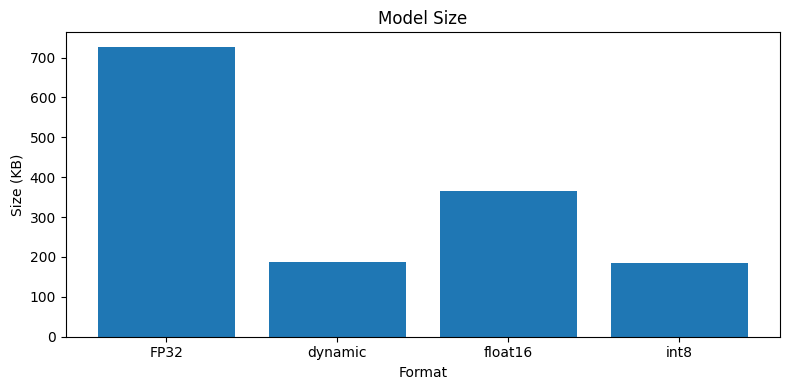

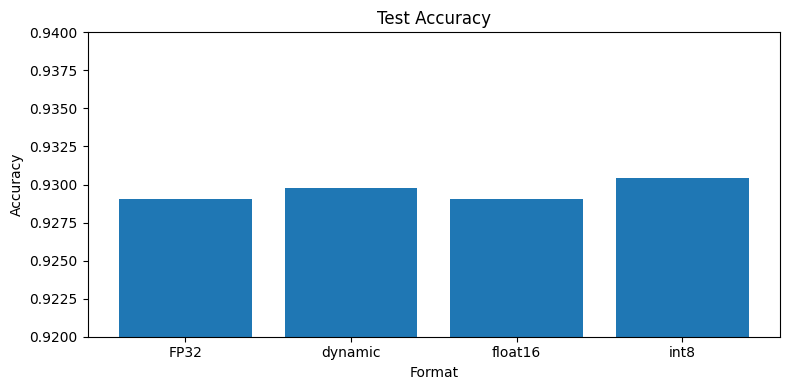

In [13]:
# Create one bar plot for model size and another for test accuracy.

# Model size plot
plt.figure(figsize=(8,4))
plt.bar(df_data["Format"], df_data["Model Size (KB)"])
plt.title("Model Size")
plt.xlabel("Format")
plt.ylabel("Size (KB)")
plt.tight_layout()
plt.show()

# Test accuracy plot
plt.figure(figsize=(8,4))
plt.bar(df_data["Format"], df_data["Test Accuracy"])
plt.title("Test Accuracy")
plt.xlabel("Format")
plt.ylabel("Accuracy")
plt.ylim(0.92, 0.94)

plt.tight_layout()
plt.show()


### Confusion Matrix for the PTQ Int8 Model


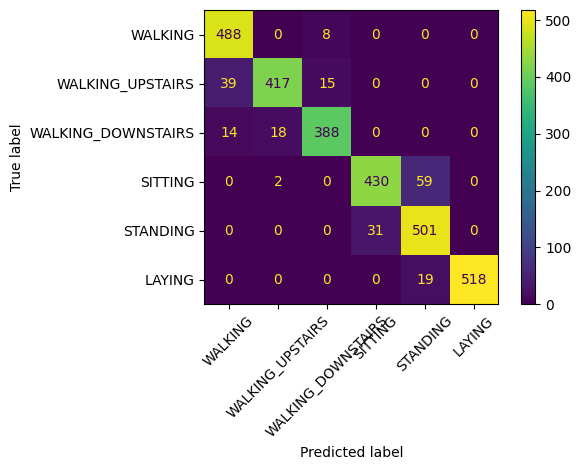

                    precision    recall  f1-score   support

           WALKING       0.90      0.98      0.94       496
  WALKING_UPSTAIRS       0.95      0.89      0.92       471
WALKING_DOWNSTAIRS       0.94      0.92      0.93       420
           SITTING       0.93      0.88      0.90       491
          STANDING       0.87      0.94      0.90       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.93      2947
         macro avg       0.93      0.93      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



In [14]:
# Plot the confusion matrix for the PTQ int8 model.
# Print the classification report for the PTQ int8 model.

cm = confusion_matrix(y_test, int8_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=45)
plt.tight_layout()
plt.show()

print(classification_report(y_test, int8_pred, target_names=class_names))


## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [15]:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

qat_model = tfmot.quantization.keras.quantize_model(baseline_model)
qat_model.compile(
    optimizer=keras.optimizers.legacy.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

qat_model.summary()


Model: "baseline_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 561)]             0         
                                                                 
 quantize_layer (QuantizeLa  (None, 561)               3         
 yer)                                                            
                                                                 
 quant_Dense1 (QuantizeWrap  (None, 256)               143877    
 perV2)                                                          
                                                                 
 quant_Dense2 (QuantizeWrap  (None, 128)               32901     
 perV2)                                                          
                                                                 
 quant_Dense3 (QuantizeWrap  (None, 64)                8261      
 perV2)                                             

### Fine-Tune the QAT Model


In [16]:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.
history_qat = qat_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64,
    verbose=1
)


Epoch 1/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0670 - accuracy: 0.9801 - val_loss: 0.1311 - val_accuracy: 0.9415
Epoch 2/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0550 - accuracy: 0.9816 - val_loss: 0.1250 - val_accuracy: 0.9436
Epoch 3/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0515 - accuracy: 0.9823 - val_loss: 0.1385 - val_accuracy: 0.9415
Epoch 4/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0481 - accuracy: 0.9847 - val_loss: 0.1239 - val_accuracy: 0.9449
Epoch 5/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0455 - accuracy: 0.9842 - val_loss: 0.1569 - val_accuracy: 0.9429
Epoch 6/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0439 - accuracy: 0.9859 - val_loss: 0.1487 - val_accuracy: 0.9443
Epoch 7/8
92/92 [==============================] - 0s 1ms/step - loss: 0.0441 - accuracy: 0.9855 - val_loss: 0.1315 - val_accuracy: 0.9429
Epoch 8/8
92/92 [==========

### Evaluate the QAT Keras Model


In [17]:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.

qat_probabilities = qat_model.predict(X_test)
qat_predictions = np.argmax(qat_probabilities, axis=1)
accuracy = accuracy_score(y_test, qat_predictions)
print("Accuracy",accuracy)
print("Classification Report")
print(classification_report(y_test, qat_predictions, target_names=class_names))


93/93 [==============================] - 0s 486us/step
Accuracy 0.9280624363759755
Classification Report
                    precision    recall  f1-score   support

           WALKING       0.93      0.95      0.94       496
  WALKING_UPSTAIRS       0.95      0.92      0.93       471
WALKING_DOWNSTAIRS       0.92      0.94      0.93       420
           SITTING       0.95      0.85      0.90       491
          STANDING       0.84      0.96      0.89       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.93      2947
         macro avg       0.93      0.93      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [18]:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

qat_int8 = convert_to_tflite_int8(qat_model)
size_qat_int8 = save_binary_model(qat_int8, OUTPUT_DIR/"QATint8.tflite")
accuracy_qat_int8, qat_int8_pred = evaluate_tflite_model(qat_int8, X_test, y_test)

INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpk1afjam6/assets


INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpk1afjam6/assets
/Users/nick/College Schoolwork Local/SP26/EE446/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-18 02:23:29.605579: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-18 02:23:29.605590: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-18 02:23:29.605687: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmpk1afjam6
2026-04-18 02:23:29.606652: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-18 02:23:29.606656: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/fol

## 12. PTQ Int8 vs QAT Int8


In [19]:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)

df_data = {
    "Model": ["PTQ", "QAT"],
    "Test Accuracy": [accuracy_int8, accuracy_qat_int8],
    "Model Size (KB)": [size_int8, size_qat_int8]
}
df = pd.DataFrame(df_data)
print(df)


  Model  Test Accuracy  Model Size (KB)
0   PTQ       0.930438       185.429688
1   QAT       0.928062       185.812500


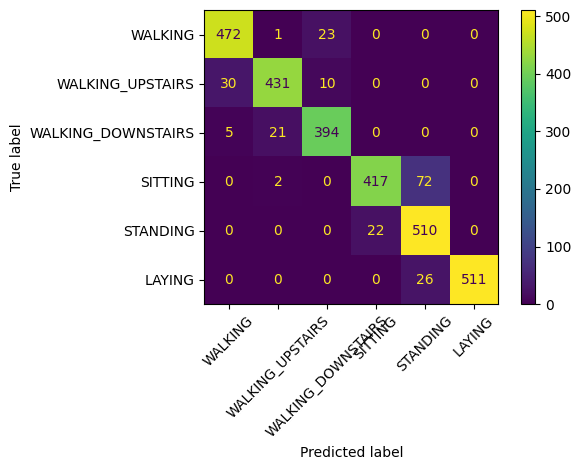

In [20]:
# Plot the confusion matrix for the QAT int8 model.

cm = confusion_matrix(y_test, qat_int8_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=45)
plt.tight_layout()
plt.show()


## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size? int8 gave the smallest model size.
2. Which quantization method gave the best accuracy among the TensorFlow Lite models? int8 gave the best accuracy.
3. Did QAT improve the final int8 model compared with PTQ int8? QAT didn't improve compared to PTQ, but the difference in accuracies is very small (0.8%).
4. Why is this dataset a good fit for a DNN-based TinyML workflow? This dataset is good for a DNN-based TinyML workflow because the dataset already has features extracted from raw sensor data. No preprocessing has to be done.
5. If you were deploying this model on a resource-constrained device, which version would you choose and why? I would choose PTQ int8 because it is slightly smaller and slightly more accurate than QAT int8. int8 quantization gives smaller and more accurate models compared to dynamic, float16, and FP32.


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
